In [1]:
from matplotlib.ticker import scale_range
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("heartAttack").getOrCreate()
df = (spark.read.option("header", "true").option("inferSchema", "true").
      csv("file:///D:/code/python/BigDataDevelopment/《大数据开发课程设计》期末考核试卷2025/Data/heart_attack.csv"))

In [2]:
columns = ["impluse", "pressurehight", "pressurelow", "glucose"]
correlation_df = df.select(columns).toPandas()
correlation_matrix = correlation_df.corr()
correlation_matrix

,impluse,pressurehight,pressurelow,glucose
impluse,1.000000,0.010882,0.108353,-0.019584
pressurehight,0.010882,1.000000,0.586166,0.020807
pressurelow,0.108353,0.586166,1.000000,-0.025614
glucose,-0.019584,0.020807,-0.025614,1.000000


In [3]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

exclude_cols = ["kcm", "troponin", "class"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df.select(feature_cols).toPandas().values
y = df.select("class").toPandas().values.ravel()

In [4]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5)
boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42)
boruta.fit(X, y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	6
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	9 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	10 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	11 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	12 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	13 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	14 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	15 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	16 / 100
Confirmed: 	1
Tentative: 	2
Rejected: 	3
Iteration: 	17 / 

BorutaPy(estimator=RandomForestClassifier(max_depth=5, n_estimators=40,
                                          random_state=RandomState(MT19937) at 0x1F2A7D44840),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x1F2A7D44840, verbose=2)

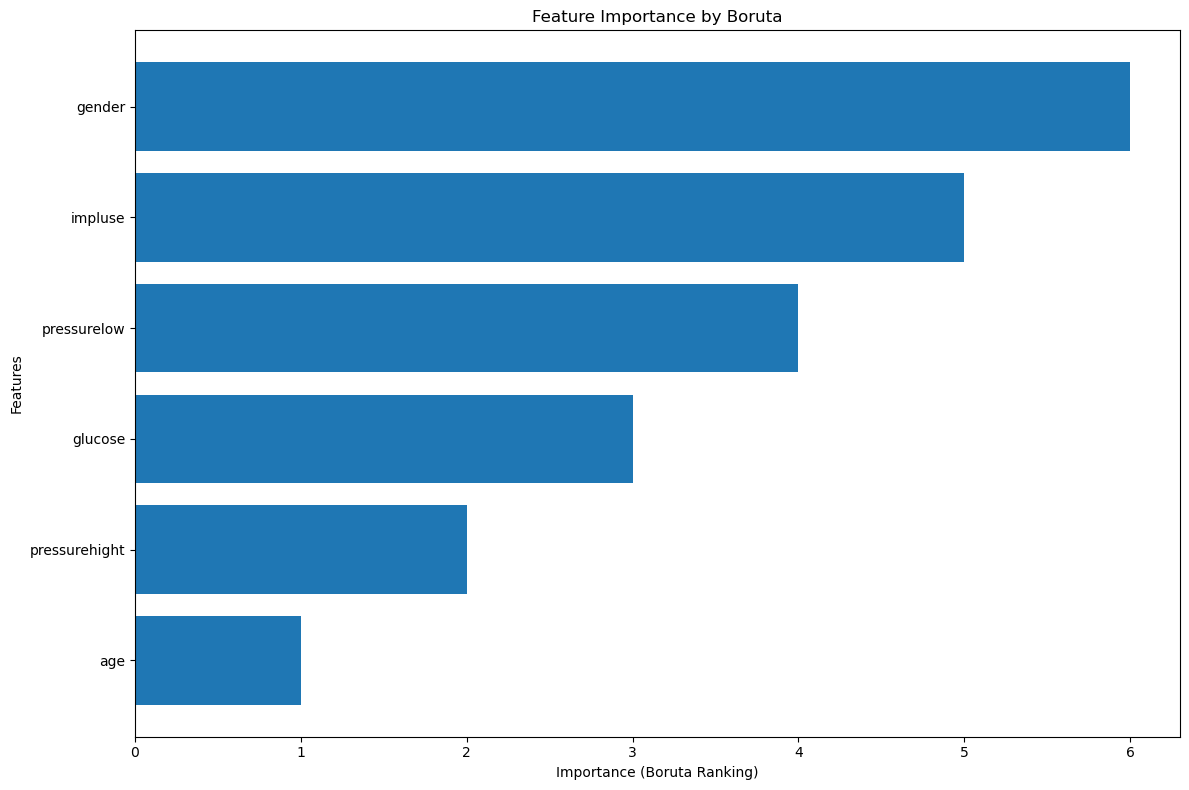

In [5]:
importance_df = pd.DataFrame({"feature": feature_cols, "importance": boruta.ranking_})
importance_df = importance_df.sort_values("importance")
plt.figure(figsize=(12, 8))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance (Boruta Ranking)")
plt.ylabel("Features")
plt.title("Feature Importance by Boruta")
plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

cols = ["impluse", "pressurehight", "pressurelow", "glucose", "kcm", "troponin"]
data = df.select(cols).toPandas()

In [7]:
for col in cols:
      stat, p = stats.shapiro(data[col])
      if p < 0.05:
            transformed, _ = stats.yeojohnson(data[col])
            data[col] = transformed
            print(f"{col}: 已进行正态化处理")
      else:
            print(f"{col}: 已满足正态性")

impluse: 已进行正态化处理
pressurehight: 已进行正态化处理
pressurelow: 已进行正态化处理
glucose: 已进行正态化处理
kcm: 已进行正态化处理
troponin: 已进行正态化处理


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from pyspark.sql.functions import when, monotonically_increasing_id

df_no_missing = df.dropna(subset=["pressurehight", "pressurelow", "glucose"])
train_data = df_no_missing.select("pressurehight", "pressurelow", "glucose", "class", "impluse").toPandas()
train_X = train_data[["pressurehight", "pressurelow", "glucose"]]
train_y = train_data["class"]

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_X, train_y)

KNeighborsClassifier()

In [12]:
for idx in [5, 88]:
      row = df.filter(monotonically_increasing_id() == idx).select("pressurehight", "pressurelow", "glucose").toPandas()
      if not row.empty:
            pred_class = knn.predict(row)[0]
            mean_value = df.filter(df["class"] == pred_class).agg({"impluse": "avg"}).collect()[0][0]
            df = df.withColumn("impluse", when(monotonically_increasing_id() == idx, mean_value).otherwise(df["impluse"]))

In [15]:
original = df.filter(monotonically_increasing_id().isin([5, 88])).select("impluse")
original.toPandas()

,impluse
0,77.886051
1,78.619753
